# 🩺 Predicción de Costos Médicos y Clasificación Tarifaria de Seguros de Salud

## 📘 Contexto del Proyecto

Las compañías de seguros de salud enfrentan el reto de definir primas justas y sostenibles para cada cliente, considerando factores demográficos y de salud que afectan directamente los costos médicos anuales. Actualmente, muchas aseguradoras aplican tarifas uniformes o segmentadas de forma poco precisa, lo cual puede generar **pérdidas financieras** o **inequidades** entre los asegurados.

Con el objetivo de mejorar la precisión en la estimación de los **costos médicos individuales** y facilitar la toma de decisiones estratégicas, este proyecto utiliza un conjunto de datos de 1338 beneficiarios de seguros de salud en Estados Unidos.  
El dataset incluye información sobre **edad, sexo, IMC (BMI), número de hijos, hábito de fumar, región de residencia** y los **costos médicos facturados (charges)**.

El proyecto se centra en desarrollar modelos de **regresión supervisada** para predecir los costos médicos esperados de nuevos clientes y, a partir de dicha predicción, **clasificar automáticamente al cliente en una categoría tarifaria**:  
- **Básica:** bajo riesgo y bajo costo médico estimado  
- **Moderada:** riesgo medio y costos intermedios  
- **Premium:** alto riesgo y altos costos médicos esperados

Este tipo de análisis permite a la aseguradora:
- Optimizar su sistema de precios.
- Incentivar hábitos de vida saludables.
- Minimizar pérdidas por subestimación de riesgo.

---

## 🎯 Objetivos Específicos

1. **Construir una línea base de predicción** utilizando un modelo de **Regresión Lineal**, evaluando su desempeño con métricas de error como MAE, RMSE y R².

2. **Explorar la correlación entre variables** y analizar la **importancia de cada factor** (edad, IMC, tabaquismo, etc.) en los costos médicos.

3. **Implementar y calcular una métrica de precisión adaptada a regresión**, el **Accuracy Epsilon**, que mide el porcentaje de predicciones con error dentro de un rango tolerable.

4. **Aplicar algoritmos de ensamble** como **Random Forest**, **Gradient Boosting**, **XGBoost** y **CatBoost**, comparando su desempeño frente al modelo base.

5. **Evaluar los modelos** en términos de:
   - Precisión predictiva  
   - Costo computacional  
   - Interpretabilidad  
   - Mantenimiento y escalabilidad  

6. **Determinar el modelo más adecuado** considerando un balance entre precisión, eficiencia y facilidad de despliegue.

7. **Desarrollar una pequeña aplicación interactiva (formulario web o en Colab)** que permita ingresar los datos de un nuevo cliente y:
   - Predecir su **costo médico anual esperado** (`charges`).
   - Clasificarlo automáticamente en una **categoría tarifaria**:
     - **Básica:** costo predicho bajo  
     - **Moderada:** costo predicho medio  
     - **Premium:** costo predicho alto  

8. **Visualizar los resultados** mediante gráficos de distribución (edad, IMC, costos) y análisis comparativos entre los distintos modelos.

---

## 🧠 Valor Agregado

Este proyecto combina análisis estadístico, machine learning y una aplicación práctica en un entorno real de seguros médicos, ofreciendo un enfoque integral que va desde la exploración de datos hasta la **implementación de un modelo predictivo aplicable a nuevos clientes**.


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

In [ ]:
!pip install kaggle

In [ ]:
  #Se le da permisos al archivo llave kaggle.json el cual permite acceder a los repositorios de kaggle.
!chmod 600 kaggle.json
#Se crea una carpeta solo para la llave a usar en kaggle.
!mkdir ~/.kaggle/
#Copia del archivo kaggle a la carpeta creada anteriormente
!cp kaggle.json ~/.kaggle/
!ls

kaggle.json  sample_data


In [ ]:
# Vamos a usar el CelebFaces Attributes (CelebA) Dataset de Kaggle
!kaggle datasets download -d mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
  0% 0.00/16.0k [00:00<?, ?B/s]
100% 16.0k/16.0k [00:00<00:00, 54.5MB/s]


In [ ]:
!unzip insurance.zip

Archive:  insurance.zip
  inflating: insurance.csv           


# Data collection / EDA


In [ ]:
dataset=pd.read_csv('insurance.csv')

In [ ]:
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


<Figure size 600x600 with 0 Axes>

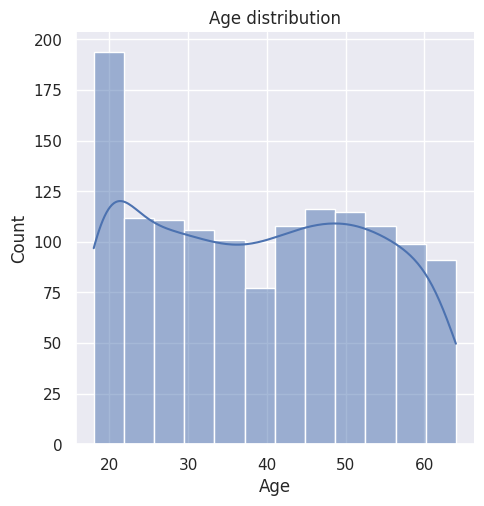

In [ ]:
sns.set()
plt.figure (figsize=(6,6))
sns.displot(dataset['age'], kde=True)
plt.xlabel('Age')
plt.title('Age distribution')
plt.show()

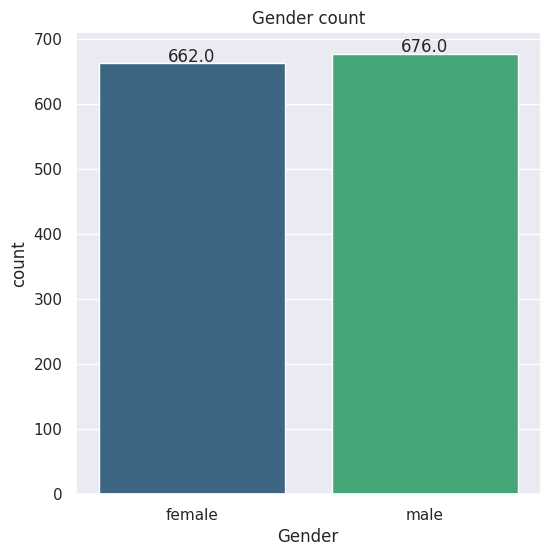

In [ ]:
sns.set()
plt.figure (figsize=(6,6))
ax = sns.countplot(x='sex', data=dataset, hue='sex', palette='viridis', legend=False)
plt.title('Gender count')
plt.xlabel('Gender')


for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

/tmp/ipython-input-166101502.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['bmi'])


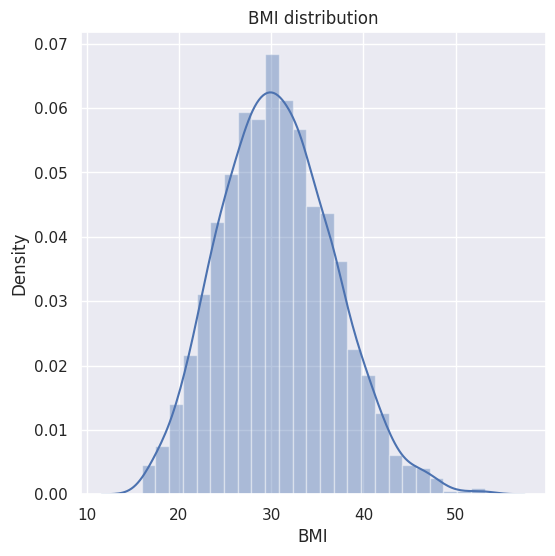

In [ ]:
sns.set()
plt.figure (figsize=(6,6))
sns.distplot(dataset['bmi'])
plt.xlabel('BMI')
plt.title('BMI distribution')
plt.show()

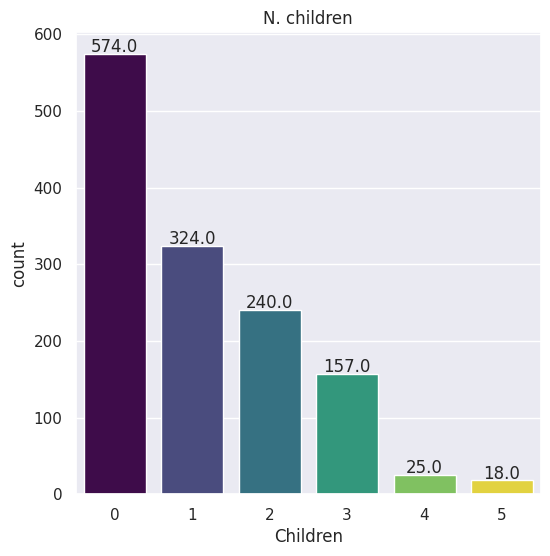

In [ ]:
sns.set()
plt.figure (figsize=(6,6))
ax = sns.countplot(x='children', data=dataset, hue='children', palette='viridis', legend=False)
plt.title('N. children')
plt.xlabel('Children')


for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

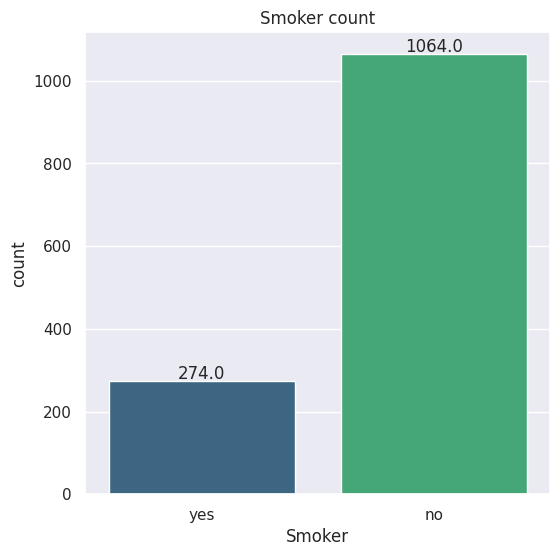

In [ ]:
sns.set()
plt.figure (figsize=(6,6))
ax = sns.countplot(x='smoker', data=dataset, hue='smoker', palette='viridis', legend=False)
plt.title('Smoker count')
plt.xlabel('Smoker')


for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

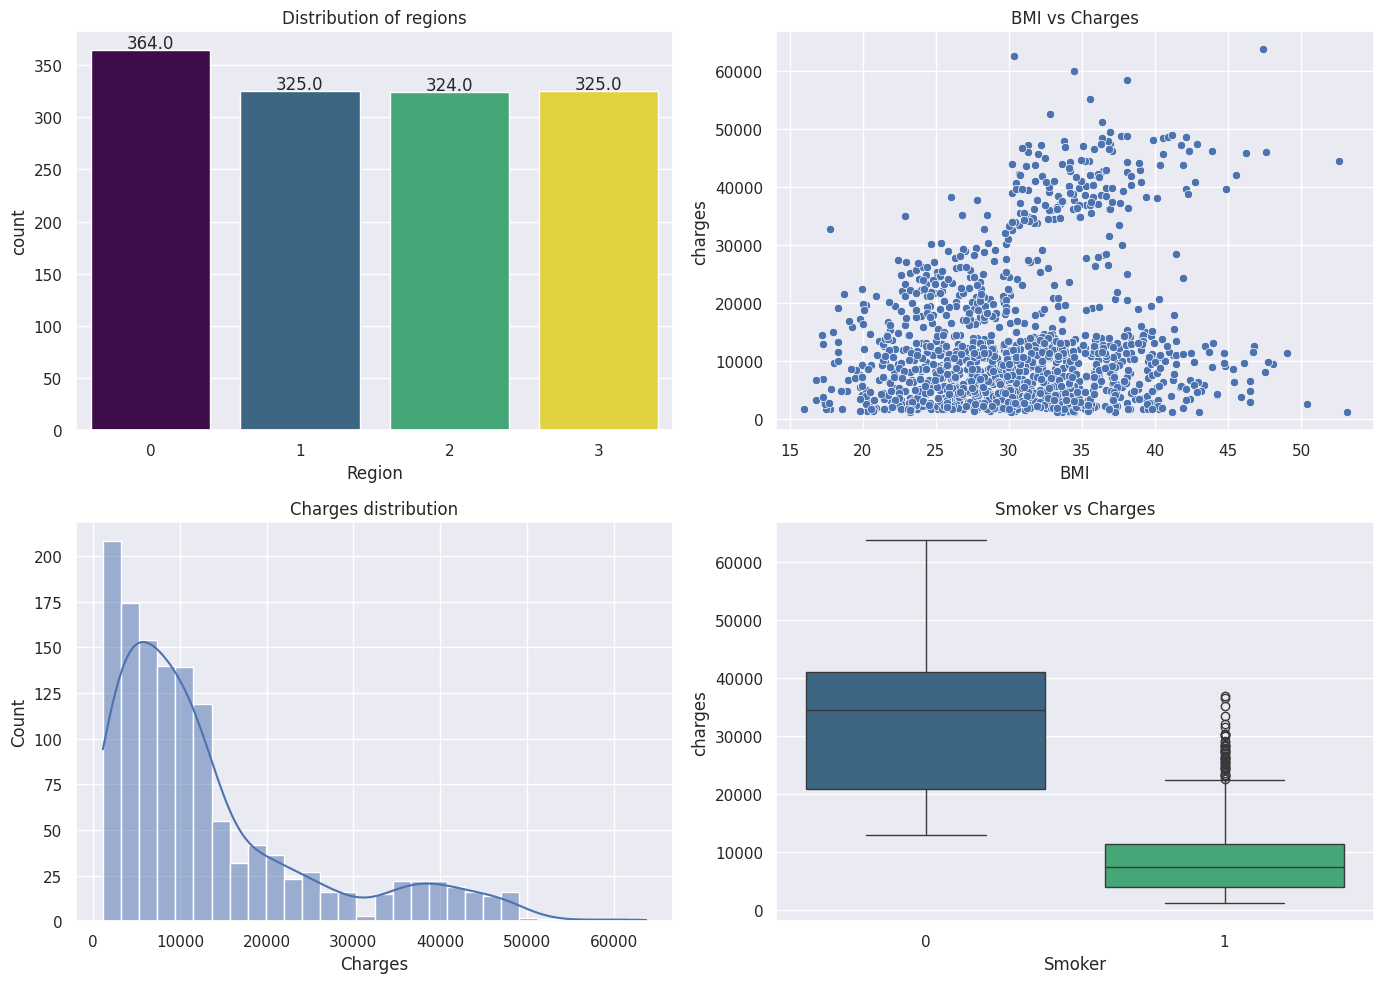

In [ ]:
sns.set()
plt.figure(figsize=(14, 10))

# Region distribution plot
plt.subplot(2, 2, 1)
ax = sns.countplot(x='region', data=dataset, hue='region', palette='viridis', legend=False)
plt.title('Distribution of regions')
plt.xlabel('Region')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Charges distribution plot
plt.subplot(2, 2, 3)
sns.histplot(dataset['charges'], kde=True) # Changed to histplot for better compatibility with subplots
plt.xlabel('Charges')
plt.title('Charges distribution')

plt.subplot(2, 2, 4)
sns.boxplot(data=dataset,x=dataset['smoker'],y=dataset['charges'],hue='smoker', palette='viridis', legend=False) # Changed to histplot for better compatibility with subplots
plt.xlabel('Smoker')
plt.title('Smoker vs Charges')


# Charges distribution plot
plt.subplot(2, 2, 2)
sns.scatterplot(data=dataset,x=dataset['bmi'],y=dataset['charges']) # Changed to histplot for better compatibility with subplots
plt.xlabel('BMI')
plt.title('BMI vs Charges')


plt.tight_layout()
plt.show()

#Data preprocessing

In [ ]:
# encoding sex column
dataset.replace({'sex':{'male':0, 'female':1}}, inplace=True)
dataset.infer_objects(copy=False)

# encoding 'smoker' column
dataset.replace({'smoker':{'yes':0, 'no':1}}, inplace=True)
dataset.infer_objects(copy=False)

# encoding 'region' column
dataset.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3}}, inplace=True)
dataset.infer_objects(copy=False)

dataset.head()

/tmp/ipython-input-2017980622.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({'sex':{'male':0, 'female':1}}, inplace=True)
/tmp/ipython-input-2017980622.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({'smoker':{'yes':0, 'no':1}}, inplace=True)
/tmp/ipython-input-2017980622.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behav

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


In [ ]:
X = dataset.drop(columns='charges', axis=1)
Y = dataset['charges']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


In [ ]:
cols_to_scale = ['age', 'bmi']
scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Entrenamiento

## Regresión lineal

In [ ]:
# Con normalizacion

from sklearn.metrics import r2_score, mean_squared_error
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

# Realizar predicciones
y_pred = model.predict(X_test_scaled)

# Evaluar el modelo
r2 = r2_score(Y_test, y_pred)
rmse = mean_squared_error(Y_test, y_pred)
mae=metrics.mean_absolute_error(Y_test, y_pred)

print(f"Coeficiente de determinación (R²): {r2:.4f}")
print(f"Error cuadrático medio (RMSE): {rmse:.2f}")
print(f"Error absoluto medio (MAE): {mae:.2f}")

Coeficiente de determinación (R²): 0.7447
Error cuadrático medio (RMSE): 38337035.49
Error absoluto medio (MAE): 4267.21


In [ ]:
# Sin normalizacion
model.fit(X_train, Y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
r2 = r2_score(Y_test, y_pred)
rmse = mean_squared_error(Y_test, y_pred)

print(f"Coeficiente de determinación (R²): {r2:.4f}")
print(f"Error cuadrático medio (RMSE): {rmse:.2f}")

Coeficiente de determinación (R²): 0.7447
Error cuadrático medio (RMSE): 38337035.49


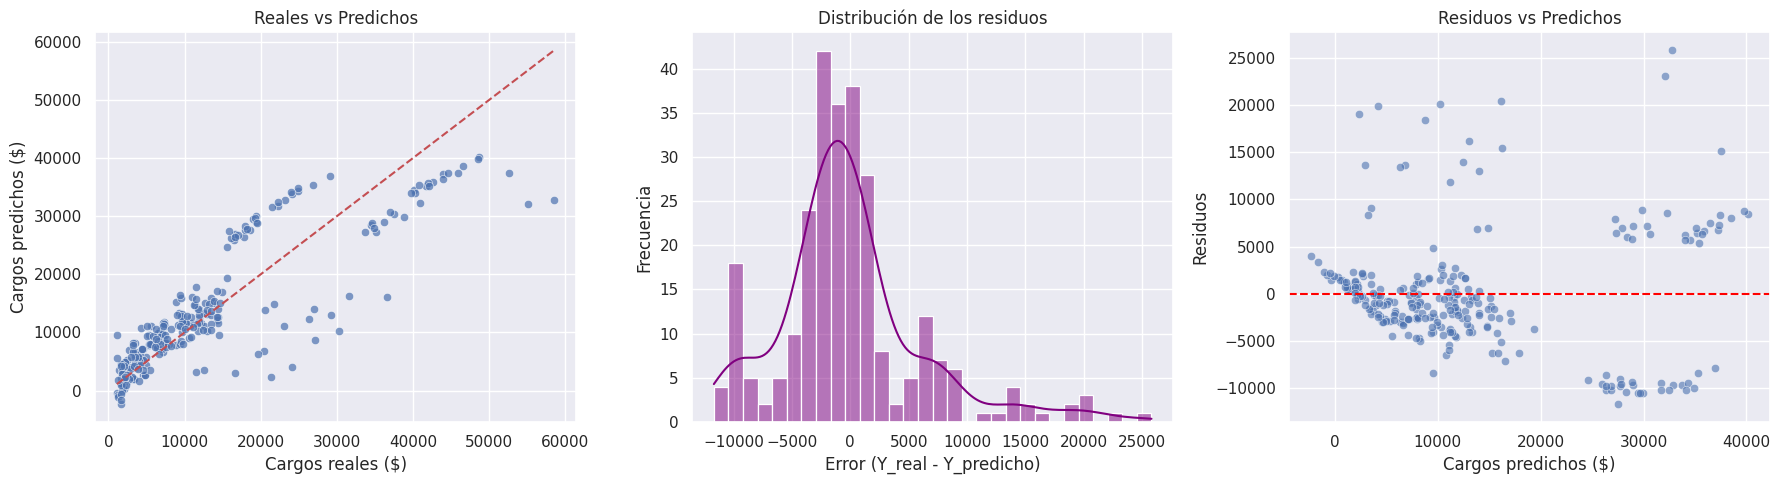

In [ ]:
plt.figure(figsize=(18, 5))

# (a) Reales vs predichos
plt.subplot(1, 3, 1)
sns.scatterplot(x=Y_test, y=y_pred, alpha=0.7)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel("Cargos reales ($)")
plt.ylabel("Cargos predichos ($)")
plt.title("Reales vs Predichos")

# (b) Distribución de residuos
residuos = Y_test - y_pred
plt.subplot(1, 3, 2)
sns.histplot(residuos, bins=30, kde=True, color='purple')
plt.title("Distribución de los residuos")
plt.xlabel("Error (Y_real - Y_predicho)")
plt.ylabel("Frecuencia")

# (c) Residuos vs predichos
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_pred, y=residuos, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs Predichos")
plt.xlabel("Cargos predichos ($)")
plt.ylabel("Residuos")

plt.tight_layout()
plt.show()

In [ ]:
coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model.coef_,
    "Importancia_Absoluta": np.abs(model.coef_) / np.sum(np.abs(model.coef_))
})

print(coef)

   Variable   Coeficiente  Importancia_Absoluta
0       age    251.405122              0.009926
1       sex     26.117160              0.001031
2       bmi    330.646372              0.013054
3  children    580.274383              0.022910
4    smoker -23928.101711              0.944701
5    region    212.222427              0.008379


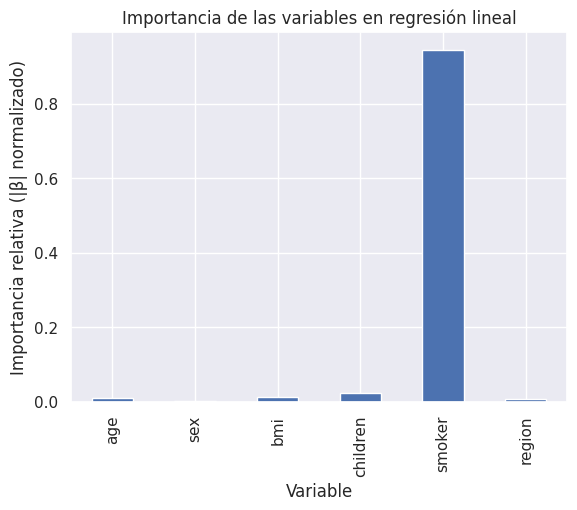

In [ ]:
coef.plot.bar(x="Variable", y="Importancia_Absoluta", legend=False)
plt.ylabel("Importancia relativa (|β| normalizado)")
plt.title("Importancia de las variables en regresión lineal")
plt.show()

In [ ]:
X_const = sm.add_constant(X_train_scaled)  # agrega el intercepto
ols_model = sm.OLS(Y_train, X_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     535.8
Date:                Wed, 22 Oct 2025   Prob (F-statistic):          3.28e-317
Time:                        14:43:41   Log-Likelihood:                -10829.
No. Observations:                1070   AIC:                         2.167e+04
Df Residuals:                    1063   BIC:                         2.171e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.144e+04    760.890     28.181      0.0

### Regresion Regularización L2

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)  # alpha = fuerza de regularización
ridge.fit(X_train_scaled, Y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

r2_ridge = r2_score(Y_test, y_pred_ridge)
rmse_ridge = mean_squared_error(Y_test, y_pred_ridge)
mae_ridge = metrics.mean_absolute_error(Y_test, y_pred_ridge)

print(f"Ridge Regression → R²: {r2_ridge:.4f} | RMSE: {rmse_ridge:.2f} | MAE: {mae_ridge:.2f}")


Ridge Regression → R²: 0.7444 | RMSE: 38386251.91 | MAE: 4253.84


In [ ]:
coef_ridge = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": ridge.coef_,
    "Importancia_Absoluta": np.abs(ridge.coef_) / np.sum(np.abs(ridge.coef_))
})

print(coef_ridge)

   Variable   Coeficiente  Importancia_Absoluta
0       age  11465.109832              0.241534
1       sex      8.490819              0.000179
2       bmi  11432.851994              0.240855
3  children    581.558429              0.012252
4    smoker -23785.862709              0.501094
5    region    193.989637              0.004087


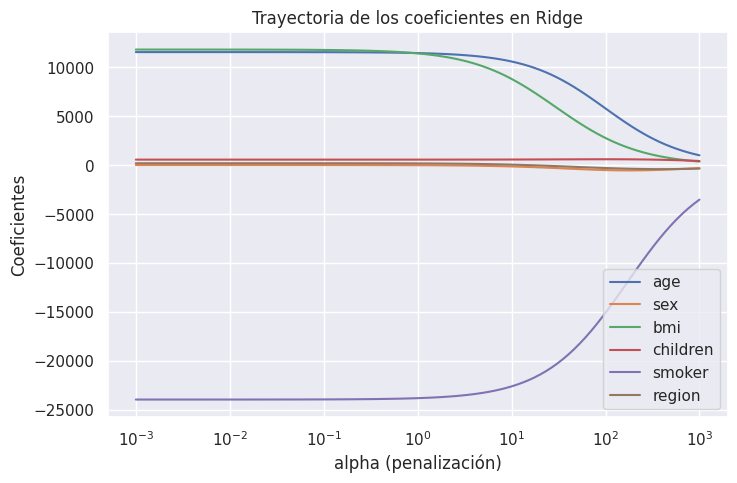

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

alphas = np.logspace(-3, 3, 100)
coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, Y_train)
    coefs.append(ridge.coef_)

plt.figure(figsize=(8,5))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('alpha (penalización)')
plt.ylabel('Coeficientes')
plt.title('Trayectoria de los coeficientes en Ridge')
plt.legend(X.columns)
plt.show()


### Regresion Regularización L1

In [ ]:
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train_scaled, Y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

r2_lasso = r2_score(Y_test, y_pred_lasso)
rmse_lasso = mean_squared_error(Y_test, y_pred_lasso)
mae_lasso =metrics.mean_absolute_error(Y_test, y_pred_lasso)

print(f"Lasso Regression → R²: {r2_lasso:.4f} | RMSE: {rmse_lasso:.2f} | MAE: {mae_lasso:.2f}")

Lasso Regression → R²: 0.7447 | RMSE: 38337040.82 | MAE: 4267.21


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'R²': [r2, r2_ridge, r2_lasso],
    'RMSE': [rmse, rmse_ridge, rmse_lasso],
    'MAE': [mae, mae_ridge, mae_lasso]
})

print(results)


   Modelo        R²          RMSE          MAE
0  Linear  0.744727  3.833704e+07  4267.213827
1   Ridge  0.744400  3.838625e+07  4253.837402
2   Lasso  0.744727  3.833704e+07  4267.211972


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train)
X_test_scaled2 = scaler2.transform(X_test)

## Random forest regressor - XGB - SVR

In [ ]:
# Modelo 2: Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, Y_train)  # sin escalar
y_pred_rf = rf.predict(X_test)

# Modelo 3: XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, Y_train)
y_pred_xgb = xgb.predict(X_test)


# Modelo 4: SVR
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled2, Y_train)

y_pred_svr = svr.predict(X_test_scaled2)

In [ ]:
def eval_model(name, y_true, y_pred):
    return {
        "Modelo": name,
        "R²": r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MAE": metrics.mean_absolute_error(y_true, y_pred)
    }

results = pd.DataFrame([
    eval_model("Linear Regression", Y_test, y_pred_ridge),
    eval_model("Random Forest", Y_test, y_pred_rf),
    eval_model("XGBoost", Y_test, y_pred_xgb),
    eval_model("SVR", Y_test, y_pred_svr),
])

print(results)

              Modelo        R²          RMSE          MAE
0  Linear Regression  0.744400  3.838625e+07  4253.837402
1      Random Forest  0.838256  2.429091e+07  2724.532459
2            XGBoost  0.823072  2.657117e+07  3214.671829
3                SVR  0.309778  1.036580e+08  5294.112449


/tmp/ipython-input-3789713469.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(results["Modelo"], rotation=35, ha='right')
/tmp/ipython-input-3789713469.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(results["Modelo"], rotation=35, ha='right')
/tmp/ipython-input-3789713469.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(results["Modelo"], rotation=35, ha='right')


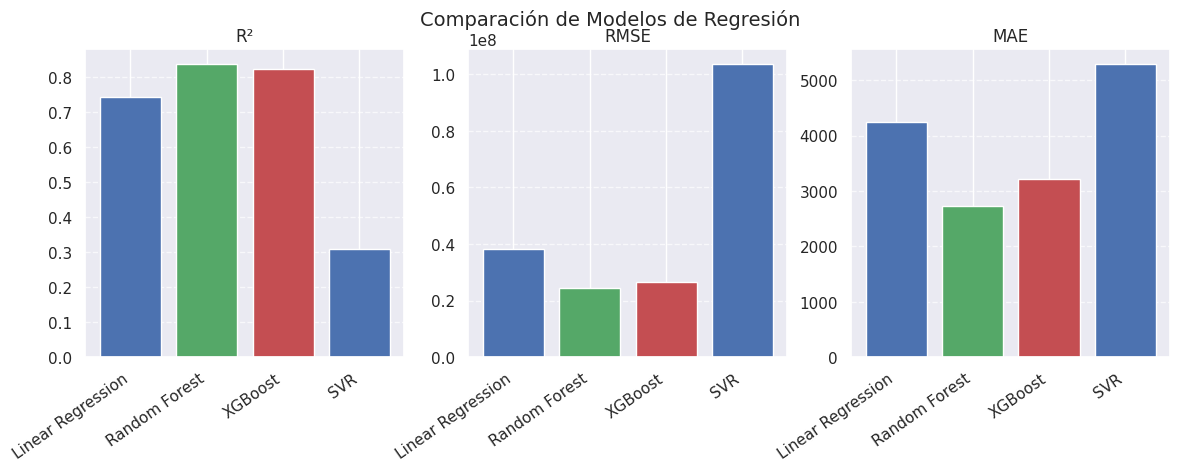

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["R²", "RMSE", "MAE"]

for i, m in enumerate(metrics):
    axs[i].bar(results["Modelo"], results[m], color=["#4C72B0", "#55A868", "#C44E52"])
    axs[i].set_title(m)
    axs[i].grid(True, axis='y', linestyle='--', alpha=0.7)
    axs[i].set_xticklabels(results["Modelo"], rotation=35, ha='right')

plt.suptitle("Comparación de Modelos de Regresión", fontsize=14)
#plt.tight_layout()
plt.show()

In [ ]:
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Random Forest Feature Importance:\n", importances_rf)
print("\nXGBoost Feature Importance:\n", importances_xgb)


Random Forest Feature Importance:
 smoker      0.628351
bmi         0.207828
age         0.125083
children    0.018264
region      0.014696
sex         0.005778
dtype: float64

XGBoost Feature Importance:
 smoker      0.865826
bmi         0.049728
age         0.038401
children    0.018919
region      0.014332
sex         0.012794
dtype: float32


/tmp/ipython-input-3297357821.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3297357821.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


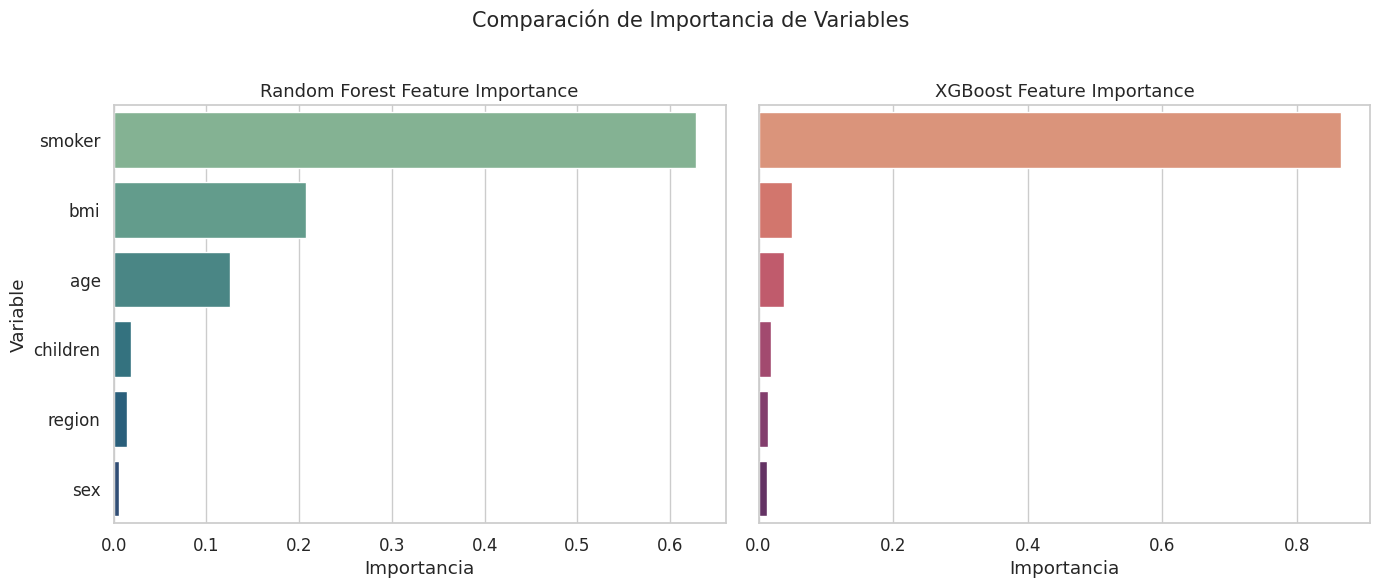

In [ ]:
# Estilo visual moderno
sns.set(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Random Forest ---
sns.barplot(
    x=importances_rf.values,
    y=importances_rf.index,
    ax=axes[0],
    palette="crest"
)
axes[0].set_title("Random Forest Feature Importance", fontsize=13)
axes[0].set_xlabel("Importancia")
axes[0].set_ylabel("Variable")

# --- XGBoost ---
sns.barplot(
    x=importances_xgb.values,
    y=importances_xgb.index,
    ax=axes[1],
    palette="flare"
)
axes[1].set_title("XGBoost Feature Importance", fontsize=13)
axes[1].set_xlabel("Importancia")
axes[1].set_ylabel("")

plt.suptitle("Comparación de Importancia de Variables", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Resumen interpretativo

Si los datos son lineales, el modelo lineal gana por simplicidad.

Si hay interacciones abruptas o categóricas, el Random Forest destaca.

Si hay relaciones suaves pero no lineales, el SVR o XGBoost suelen dominar.

Si hay ruido o outliers, el Random Forest o XGBoost son más resistentes

# Busqueda hiperparametros

In [ ]:
param_distributions = {
    'n_estimators': np.arange(160, 260, 20),       # número de árboles
    'max_depth': [None, 2,3,4,5,7,8],          # profundidad máxima
    'min_samples_split': [8,10,12,15],                 # mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 3],                   # mínimo de muestras por hoja
    'max_features': [0.1,0.3,0.5,0.7, 1.0, 'sqrt', 'log2', None],        # número de features a considerar por división
    'bootstrap': [True, False]                       # si se usa muestreo bootstrap
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Definir búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=150,               # número de combinaciones a probar (ajusta según tiempo disponible)
    scoring='r2',            # métrica a optimizar
    cv=3,                    # validación cruzada k-fold
    verbose=2,
    random_state=42,
    n_jobs=-1                # usa todos los núcleos disponibles
)

# Entrenar búsqueda
random_search.fit(X_train, Y_train)


Fitting 3 folds for each of 150 candidates, totalling 450 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
162 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils

RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                                   random_state=42),
                   n_iter=150, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 20, 30, 50,
                                                      100],
                                        'max_features': [0.1, 0.3, 0.5, 0.7, 1,
                                                         1.3, 1.5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([100, 200, 300, 400, 500, 600, 700, 800, 900])},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Definir búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=150,               # número de combinaciones a probar (ajusta según tiempo disponible)
    scoring='r2',            # métrica a optimizar
    cv=3,                    # validación cruzada k-fold
    verbose=2,
    random_state=42,
    n_jobs=-1                # usa todos los núcleos disponibles
)

# Entrenar búsqueda
random_search.fit(X_train, Y_train)

Fitting 3 folds for each of 150 candidates, totalling 450 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                                   random_state=42),
                   n_iter=150, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 2, 3, 4, 5, 7, 8],
                                        'max_features': [0.1, 0.3, 0.5, 0.7,
                                                         1.0, 'sqrt', 'log2',
                                                         None],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [8, 10, 12, 15],
                                        'n_estimators': array([160, 180, 200, 220, 240])},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

print("\nMejor puntaje (R² promedio CV):")
print(random_search.best_score_)


Mejores hiperparámetros encontrados:
{'n_estimators': np.int64(200), 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 5, 'bootstrap': True}

Mejor puntaje (R² promedio CV):
0.8493245237836103


In [ ]:
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

print("\nMejor puntaje (R² promedio CV):")
print(random_search.best_score_)

Mejores hiperparámetros encontrados:
{'n_estimators': np.int64(220), 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 5, 'bootstrap': True}

Mejor puntaje (R² promedio CV):
0.8493263010948896


In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

r2 = r2_score(Y_test, y_pred_rf)
rmse = mean_squared_error(Y_test, y_pred_rf)
mae = mean_absolute_error(Y_test, y_pred_rf)

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


R²: 0.8677
RMSE: 19873977.02
MAE: 2431.42


### Mejor modelo


In [ ]:
import joblib

# Save the best Random Forest model
joblib.dump(best_rf, 'best_random_forest_model.pkl')

print("Best Random Forest model saved as 'best_random_forest_model.pkl'")

Best Random Forest model saved as 'best_random_forest_model.pkl'


In [ ]:
import numpy as np

def accuracy_epsilon_dynamic(y_true, y_pred):
    """
    Calcula un accuracy adaptativo basado en tolerancias dinámicas
    según percentiles de la variable objetivo.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    errors = np.abs(y_true - y_pred)

    # Calcular percentiles de referencia (ajustables)
    p50 = np.percentile(y_true, 50)
    p90 = np.percentile(y_true, 90)

    acc_flags = []

    for real, err in zip(y_true, errors):
        if real <= p50:
            epsilon = 0.25 * real      # ±10% tolerancia
        elif real <= p90:
            epsilon = 0.20 * real      # ±5%
        else:
            epsilon = 0.15 * real      # ±2%

        acc_flags.append(err <= epsilon)

    return np.mean(acc_flags)


In [ ]:
acc = accuracy_epsilon_dynamic(Y_test, y_pred_rf)
print(f"Accuracy-ε dinámico: {acc:.3f}")

Accuracy-ε dinámico: 0.563


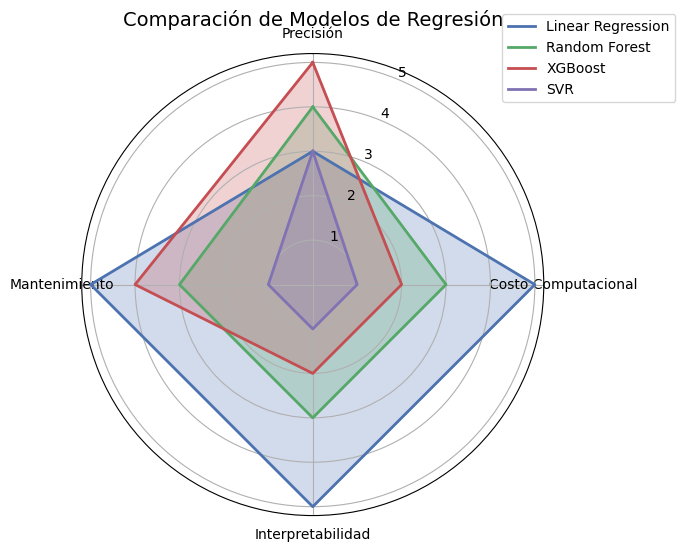

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Modelos y criterios
modelos = ["Linear Regression", "Random Forest", "XGBoost", "SVR"]
criterios = ["Precisión", "Costo Computacional", "Interpretabilidad", "Mantenimiento"]

# Escala 1–5 (5 = mejor desempeño relativo)
scores = np.array([
    [3, 5, 5, 5],  # Linear Regression
    [4, 3, 3, 3],  # Random Forest
    [5, 2, 2, 4],  # XGBoost
    [3, 1, 1, 1],  # SVR
])

# Crear gráfico radar
num_vars = len(criterios)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
scores = np.concatenate((scores, scores[:, [0]]), axis=1)  # cerrar el polígono
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]

for i in range(len(modelos)):
    ax.plot(angles, scores[i], color=colors[i], linewidth=2, label=modelos[i])
    ax.fill(angles, scores[i], color=colors[i], alpha=0.25)

# Etiquetas y formato
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), criterios)
ax.set_title("Comparación de Modelos de Regresión", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()
